# Imports/utility functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
%run ../commonvis.py

In [2]:
ablations = pd.read_csv('_results/ablationresults.csv')
allperplexities = pd.read_csv('_results/allperplexities.csv')

methods = [
        'vima',
        'vima-nosid',
        'vima-nocvae-noresnet',
        'cluster',
           ]

# Main text figure

In [3]:
ablations

,Unnamed: 0.1,Unnamed: 0,pheno,method,p,npos,nneg,total,scaled_total,logp
0,0,0,ALZ,vima-nocvae-noresnet,0.005994,505,984,1489,0.027027,2.222283
1,1,1,ALZ,cluster,0.086391,18945,16345,35290,0.640553,1.063530
2,2,2,ALZ,vima-nosid,0.019980,13649,16161,29810,0.541085,1.699404
3,3,3,ALZ,vima,0.004995,33342,21751,55093,1.000000,2.301464
4,4,4,RA,vima-nocvae-noresnet,0.000200,13,14,27,0.004757,3.699013
5,5,5,RA,cluster,0.352765,0,420,420,0.073996,0.452515
6,6,6,RA,vima-nosid,0.000200,2418,3463,5881,1.036117,3.699013
7,7,7,RA,vima,0.000200,2294,3382,5676,1.000000,3.699013
8,8,8,UC,vima-nocvae-noresnet,0.010099,3,461,464,0.042121,1.995722
9,9,9,TNFi,vima-nocvae-noresnet,1.000000,0,0,0,0.000000,-0.000000


In [4]:
def ablations_comparison(ax):
    np.random.seed(0)
    ablations_copy = ablations.copy() # to return at the end

    phenos = ['RA', 'UC', 'TNFi', 'Dementia']
    markers = ['o', 'x', 's', '^']  # circle, x, square, triangle

    palette = sns.color_palette("viridis", n_colors=4)
    palette[0] = (1.0, 0.647, 0.0)

    # add jitter where necessary
    ablations.loc[ablations.logp == 0, 'logp'] += np.random.choice([-1,1], size=(ablations.logp == 0).sum())*0.005
    ablations.loc[ablations.scaled_total == 0, 'scaled_total'] += np.random.choice([-1,1], size=(ablations.scaled_total == 0).sum())*0.005
    for method in methods:
        toplot = ablations[ablations.method == method].set_index('pheno')
        toplot.index = toplot.index.str.replace('ALZ','Dementia')
        toplot = toplot.loc[phenos]
        
        # Plot each point with its own marker
        for i, (pheno, row) in enumerate(toplot.iterrows()):
            ax.plot(
                row.logp,
                row.scaled_total,
                marker=markers[i], markersize=7,
                color=palette[methods.index(method)],  # consistent color per pheno
                alpha=0.9,
                label=methodnames[method] if i == 0 else None
            )

    # Legend for method (color)
    method_handles = [
        mlines.Line2D([], [], color=palette[i], marker='o', linestyle='None', label=methodnames[m])
        for i, m in enumerate(methods)
    ]

    # Legend for pheno (marker)
    pheno_handles = [
        mlines.Line2D([], [], color='gray', marker=markers[i], linestyle='None', label=phenos[i])
        for i in range(len(phenos))
    ]

    # Add both legends
    first_legend = ax.legend(handles=method_handles, title='Method', loc='upper left', fontsize=fs_legend)
    ax.add_artist(first_legend)  # keep the first legend
    ax.legend(handles=pheno_handles, title='Phenotype', loc='center left', fontsize=fs_legend)

    ax.set_xlabel("$-\\log_{10}(P)$", fontsize=fs_axislabel+1)
    ax.set_ylabel("Relative #sig. patches", fontsize=fs_axislabel+1)
    ax.set_xticks([0,1,2,3])
    ax.set_yticks([0,0.5,1])
    ax.set_xlim(-0.1,4)
    ax.set_ylim(-0.04,1.1)
    ax.spines[['top','right']].set_visible(False)

    return ablations_copy[['pheno', 'method', 'p', 'scaled_total']].rename(
        columns={
            'pheno' :'Phenotype',
            'method':'Method',
            'scaled_total':'Relative #sig. patches'})

def integration_comparison(ax, rankorder=False):
    medianperps = allperplexities.groupby(['dset','method']).perplexity.aggregate(np.median).reset_index()
    if rankorder:
        medianperps['perplexity'] = medianperps.groupby('dset')['perplexity'].rank(method='min', ascending=False)
        ylabel = 'Rank(median relative perplexity)'
    else:
        ylabel = 'Median relative perplexity'
    medianperps.method = medianperps.method.map(methodnames)
    medianperps.dset = medianperps.dset.str.replace('ALZ','Dementia')
    avg_per_method = (
        medianperps.groupby('method')['perplexity']
        .mean()
        .reset_index()
        .assign(dset='Average')
    )
    sort_order = avg_per_method.sort_values(by='perplexity').method
           
    plt.figure(figsize=(6, 4))
    sns.stripplot(
        data=medianperps,
        x='method',
        y='perplexity',
        hue='dset',
        order=sort_order,
        palette=["#0011ff", "#ff0e0e", "#920eca"],
        jitter=0.15 if rankorder else False,
        size=8,
        ax=ax
    )
    sns.stripplot(
        data=avg_per_method,
        x='method',
        y='perplexity',
        hue='dset',
        palette=['#000000'],
        jitter=False,
        size=12, alpha=0.7,
        ax=ax
    )
    ax.set_xlabel('')
    ax.set_ylabel(ylabel, fontsize=fs_axislabel+1)
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_yticks([0,0.2])
    ax.legend(title='Dataset', fontsize=fs_legend+1)

    return medianperps[['dset', 'method', 'perplexity']].rename(
        columns={
            'dset':'Dataset',
            'method':'Method',
            'perplexity':ylabel
        })

/var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/ipykernel_32971/1597383339.py:62: FutureWarning: The provided callable <function median at 0x112878cc0> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  medianperps = allperplexities.groupby(['dset','method']).perplexity.aggregate(np.median).reset_index()


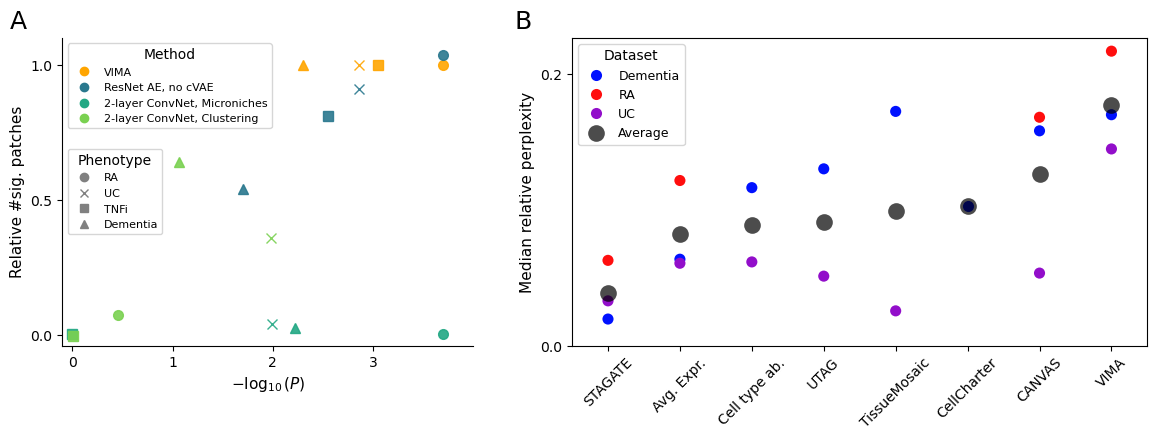

<Figure size 600x400 with 0 Axes>

In [5]:
# figure size parameters
sourcedata = {}
figsize = (14,4)
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=figsize)
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.4], wspace=0.2)

sourcedata['A. Ablations comparison'] = ablations_comparison(fig.add_subplot(gs[0, 0]))
sourcedata['B. Integration comparison'] = integration_comparison(fig.add_subplot(gs[0, 1]), rankorder=False)

# subpart labels
fig.text(0.1, 0.95, 'A', fontsize=fs_figsubpanel+4, fontweight='medium', va='top', ha='right')
fig.text(0.46, 0.95, 'B', fontsize=fs_figsubpanel+4, fontweight='medium', va='top', ha='right')

plt.tight_layout()
fig.savefig('../_main/fig.ablation_integration.pdf', bbox_inches='tight')
fig.savefig('../_main/fig.ablation_integration.png', bbox_inches='tight', dpi=1000)
plt.show()

write_sourcedata(sourcedata, '../_main/fig.ablation_integration.xlsx')